In [1]:
import numpy as np
import matplotlib.pyplot as plt
import  pandas as pd


In [2]:
dataset = pd.read_csv("bill_authentication.csv")
dataset.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [5]:

X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values


In [6]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=0)

In [7]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy',random_state= 0)
classifier.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [8]:
y_pred = classifier.predict(X_test)
print(y_pred.shape,y_test.shape)

(275,) (275,)


In [9]:
from sklearn.metrics import confusion_matrix,accuracy_score
print(y_test.shape)
cm = confusion_matrix(y_test, y_pred)
print(cm)

accuracy = accuracy_score (y_test, y_pred)*100
print('Accuracy is ' + str(accuracy) + ' %.')

(275,)
[[154   3]
 [  1 117]]
Accuracy is 98.54545454545455 %.


In [10]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       157
           1       0.97      0.99      0.98       118

    accuracy                           0.99       275
   macro avg       0.98      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



In [11]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
text_representation = tree.export_text(classifier)
print(text_representation)

|--- feature_0 <= 0.27
|   |--- feature_1 <= 5.87
|   |   |--- feature_2 <= 6.75
|   |   |   |--- feature_0 <= -0.26
|   |   |   |   |--- class: 1
|   |   |   |--- feature_0 >  -0.26
|   |   |   |   |--- feature_0 <= -0.25
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- feature_0 >  -0.25
|   |   |   |   |   |--- class: 1
|   |   |--- feature_2 >  6.75
|   |   |   |--- feature_1 <= -4.80
|   |   |   |   |--- class: 1
|   |   |   |--- feature_1 >  -4.80
|   |   |   |   |--- class: 0
|   |--- feature_1 >  5.87
|   |   |--- feature_0 <= -3.44
|   |   |   |--- feature_3 <= -1.92
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  -1.92
|   |   |   |   |--- class: 0
|   |   |--- feature_0 >  -3.44
|   |   |   |--- class: 0
|--- feature_0 >  0.27
|   |--- feature_0 <= 2.39
|   |   |--- feature_2 <= -2.18
|   |   |   |--- feature_1 <= 6.42
|   |   |   |   |--- class: 1
|   |   |   |--- feature_1 >  6.42
|   |   |   |   |--- class: 0
|   |   |--- feature_2 >  -2.18
|   |   |   |

[Text(0.5208333333333334, 0.9375, 'x[0] <= 0.274\nentropy = 0.992\nsamples = 1097\nvalue = [605, 492]'),
 Text(0.3125, 0.8125, 'x[1] <= 5.865\nentropy = 0.679\nsamples = 524\nvalue = [94, 430]'),
 Text(0.4166666666666667, 0.875, 'True  '),
 Text(0.16666666666666666, 0.6875, 'x[2] <= 6.746\nentropy = 0.278\nsamples = 416\nvalue = [20, 396]'),
 Text(0.08333333333333333, 0.5625, 'x[0] <= -0.257\nentropy = 0.032\nsamples = 304\nvalue = [1, 303]'),
 Text(0.041666666666666664, 0.4375, 'entropy = 0.0\nsamples = 266\nvalue = [0, 266]'),
 Text(0.125, 0.4375, 'x[0] <= -0.248\nentropy = 0.176\nsamples = 38\nvalue = [1, 37]'),
 Text(0.08333333333333333, 0.3125, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.16666666666666666, 0.3125, 'entropy = 0.0\nsamples = 37\nvalue = [0, 37]'),
 Text(0.25, 0.5625, 'x[1] <= -4.8\nentropy = 0.657\nsamples = 112\nvalue = [19, 93]'),
 Text(0.20833333333333334, 0.4375, 'entropy = 0.0\nsamples = 93\nvalue = [0, 93]'),
 Text(0.2916666666666667, 0.4375, 'entro

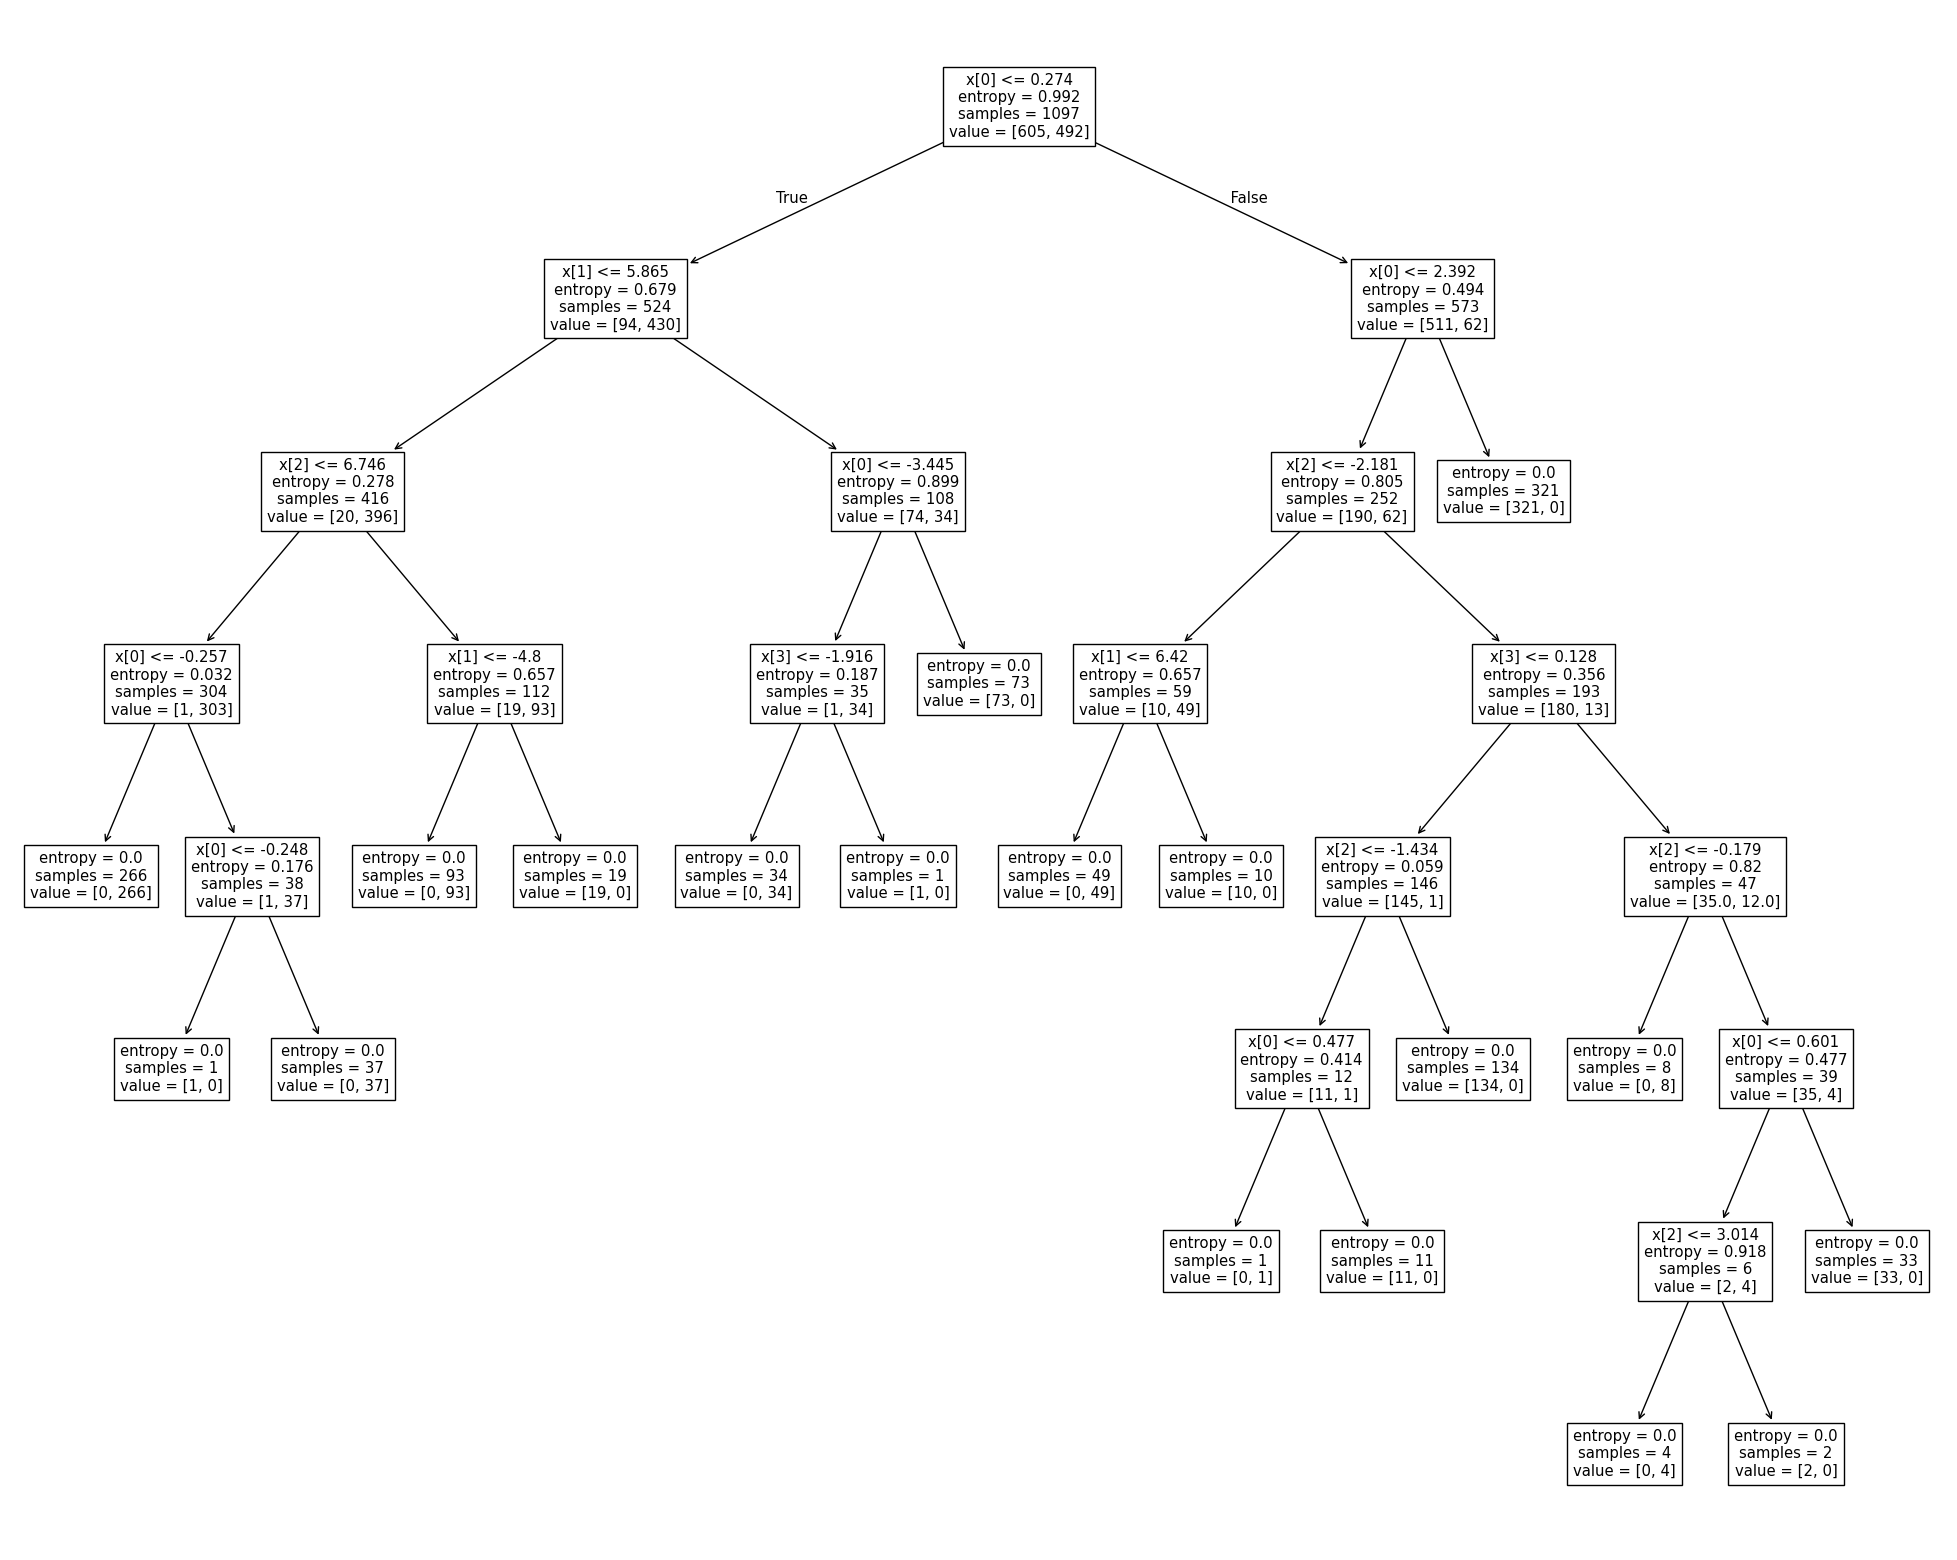

In [12]:
fig = plt.figure(figsize=(25,20))
tree.plot_tree(classifier)